# Plot SDAN vs sciRED and Spectra from saved CSV results

This notebook only loads existing result CSV files and draws scatterplots.


In [141]:
import os
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score

sns.set_theme(context="notebook", style="white")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)


In [142]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "SDAN_Comparison").exists() and ((path / "Su_2020").exists() or (path / "SEA_AD").exists() or (path / "Yost_2019").exists()):
            return path
    raise FileNotFoundError("Could not locate repo root containing SDAN_Comparison/ and a supported dataset directory.")


DATASET_CONFIG = {
    "Su_2020": {
        "study_dir": "Su_2020",
        "cell_types": ["cd4_BL", "cd8_BL"],
        "spectra_gene_list": "gene_list_cd4_cd8_union.txt",
        "spectra_loading": "train_s_cd4_cd8_BL_Spectra_union.npy",
        "scired_titles": ["sciRED CD4", "sciRED CD8"],
        "spectra_titles": ["Spectra CD4", "Spectra CD8"],
    },
    "SEA_AD": {
        "study_dir": "SEA_AD",
        "cell_types": ["Astro", "Micro-PVM"],
        "spectra_gene_list": "gene_list_Astro_Micro-PVM_union_filtered.txt",
        "spectra_loading": "train_s_Astro_Micro-PVM_union.npy",
        "scired_titles": ["sciRED Astro", "sciRED Micro-PVM"],
        "spectra_titles": ["Spectra Astro", "Spectra Micro-PVM"],
    },
    "Yost_2019": {
        "study_dir": "Yost_2019",
        "cell_types": ["CD8T"],
        "spectra_gene_list": "gene_list_CD8T_Spectra.txt",
        "spectra_loading": "train_s_CD8T_Spectra.npy",
        "scired_titles": ["sciRED CD8T"],
        "spectra_titles": ["Spectra CD8T"],
    },
}


DATASET = "Yost_2019"
if DATASET not in DATASET_CONFIG:
    raise ValueError(f"Unsupported dataset: {DATASET}. Choose from {sorted(DATASET_CONFIG)}")

REPO_ROOT = find_repo_root()
DATASET_INFO = DATASET_CONFIG[DATASET]
CELL_TYPES = DATASET_INFO["cell_types"]
DEFAULT_WEIGHT = "2.0"
CONNECTIVITY_WEIGHT_DEFAULT = DEFAULT_WEIGHT
CONNECTIVITY_THRESHOLD_DEFAULT = 0.8

SDAN_OUTPUT = REPO_ROOT / DATASET_INFO["study_dir"] / "output"
SCIRED_OUTPUT = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "sciRED"
SPECTRA_OUTPUT = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "Spectra"
RESULTS_DIR = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "SDAN_vs_sciRED_loading"
SPECTRA_RESULTS_DIR = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "SDAN_vs_Spectra_loading"
FIG_DIR = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SPECTRA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATASET: {DATASET}")
print(f"RESULTS_DIR: {RESULTS_DIR}")


REPO_ROOT: /Users/zxlin/Documents/GitHub/SDAN
DATASET: Yost_2019
RESULTS_DIR: /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Yost_2019/output_comparison/SDAN_vs_sciRED_loading


In [143]:
TITLE_FONTSIZE = 11
LABEL_FONTSIZE = 10
TICK_FONTSIZE = 9


def plot_saved_best_match_score_1x2(
    best_df: pd.DataFrame,
    cell_types: list[str],
    panel_titles: list[str],
    score_col: str = "average_precision",
    hue_col: Optional[str] = None,
    palette: str = "viridis",
    suptitle: str = "",
    save_path: Optional[Path] = None,
):
    n_panels = len(cell_types)
    if n_panels != len(panel_titles):
        raise ValueError("cell_types and panel_titles must have the same length")
    fig_width = 3.5 * n_panels + 0.5
    fig, axes = plt.subplots(1, n_panels, figsize=(fig_width, 3), dpi=300, sharey=True)
    axes = np.atleast_1d(axes)

    global_vmin = None
    global_vmax = None
    if hue_col is not None and hue_col in best_df.columns:
        hue_all = pd.to_numeric(best_df[hue_col], errors="coerce")
        if hue_all.notna().any():
            global_vmin = float(hue_all.min())
            global_vmax = float(hue_all.max())

    scatter_for_colorbar = None
    for ax, cell_type, panel_title in zip(axes, cell_types, panel_titles):
        plot_df = best_df[best_df["cell_type"] == cell_type].copy()
        if plot_df.empty:
            ax.set_visible(False)
            continue

        if hue_col is not None and hue_col in plot_df.columns:
            hue_values = pd.to_numeric(plot_df[hue_col], errors="coerce")
            valid = hue_values.notna()
            if valid.any():
                scatter = ax.scatter(
                    plot_df.loc[valid, score_col],
                    plot_df.loc[valid, "connectivity_quantile"],
                    c=hue_values.loc[valid],
                    cmap=palette,
                    s=70,
                    vmin=global_vmin,
                    vmax=global_vmax,
                )
                scatter_for_colorbar = scatter
                if (~valid).any():
                    ax.scatter(
                        plot_df.loc[~valid, score_col],
                        plot_df.loc[~valid, "connectivity_quantile"],
                        color="lightgray",
                        s=70,
                    )
            else:
                ax.scatter(plot_df[score_col], plot_df["connectivity_quantile"], s=70)
        else:
            ax.scatter(plot_df[score_col], plot_df["connectivity_quantile"], s=70)

        ax.set_title(panel_title, fontsize=TITLE_FONTSIZE, fontweight="bold")
        x_label = "AUC" if score_col.lower() == "auroc" else ("AP" if score_col.lower() == "average_precision" else score_col.replace("_", " ").title())
        ax.set_xlabel(x_label, fontsize=LABEL_FONTSIZE, fontweight="bold")
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight("bold")

    axes[0].set_ylabel("Connectivity quantile", fontsize=LABEL_FONTSIZE, fontweight="bold")
    if scatter_for_colorbar is not None and hue_col is not None:
        cbar_x = 0.91 if n_panels > 1 else 0.86
        right_margin = cbar_x - 0.03
        fig.subplots_adjust(right=right_margin)
        cax = fig.add_axes([cbar_x, 0.20, 0.02, 0.62])
        cbar = fig.colorbar(scatter_for_colorbar, cax=cax)
        cbar.set_label("Individual level AUC", fontsize=LABEL_FONTSIZE, fontweight="bold")
        cbar.ax.tick_params(labelsize=TICK_FONTSIZE)
        for tick in cbar.ax.get_yticklabels():
            tick.set_fontweight("bold")

    if scatter_for_colorbar is None:
        fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[SAVED] {save_path}")
    plt.show()


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,CD8T,2.0,SDAN_30,sciRED_9,739,25,13,0.926467,0.319252,25,4,0.320000,0.641,0.531135,0.589954
1,CD8T,2.0,SDAN_38,sciRED_11,739,25,13,0.687116,0.277891,25,0,0.000000,0.000,0.431486,0.507844
2,CD8T,2.0,SDAN_27,sciRED_39,739,26,4,0.704762,0.274566,26,2,0.153846,0.335,0.511475,0.523066
3,CD8T,2.0,SDAN_1,sciRED_18,739,23,19,0.676681,0.256756,23,106,9.217391,1.000,0.474966,0.794388
4,CD8T,2.0,SDAN_31,sciRED_7,739,24,17,0.549780,0.211455,24,22,1.833333,0.997,0.427459,0.476142


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,CD8T,2.0,SDAN_27,sciRED_24,739,26,4,0.932313,0.049821,26,2,0.153846,0.335,0.511475,0.523066
1,CD8T,2.0,SDAN_30,sciRED_9,739,25,13,0.926467,0.319252,25,4,0.320000,0.641,0.531135,0.589954
2,CD8T,2.0,SDAN_25,sciRED_11,739,25,10,0.788066,0.049036,25,6,0.480000,0.822,0.467893,0.626990
3,CD8T,2.0,SDAN_35,sciRED_9,739,24,12,0.781178,0.079697,24,0,0.000000,0.000,0.482020,0.552680
4,CD8T,2.0,SDAN_29,sciRED_21,739,26,9,0.772146,0.039389,26,0,0.000000,0.000,0.501732,0.502507


[SAVED] /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Yost_2019/figures/scired_auc.pdf


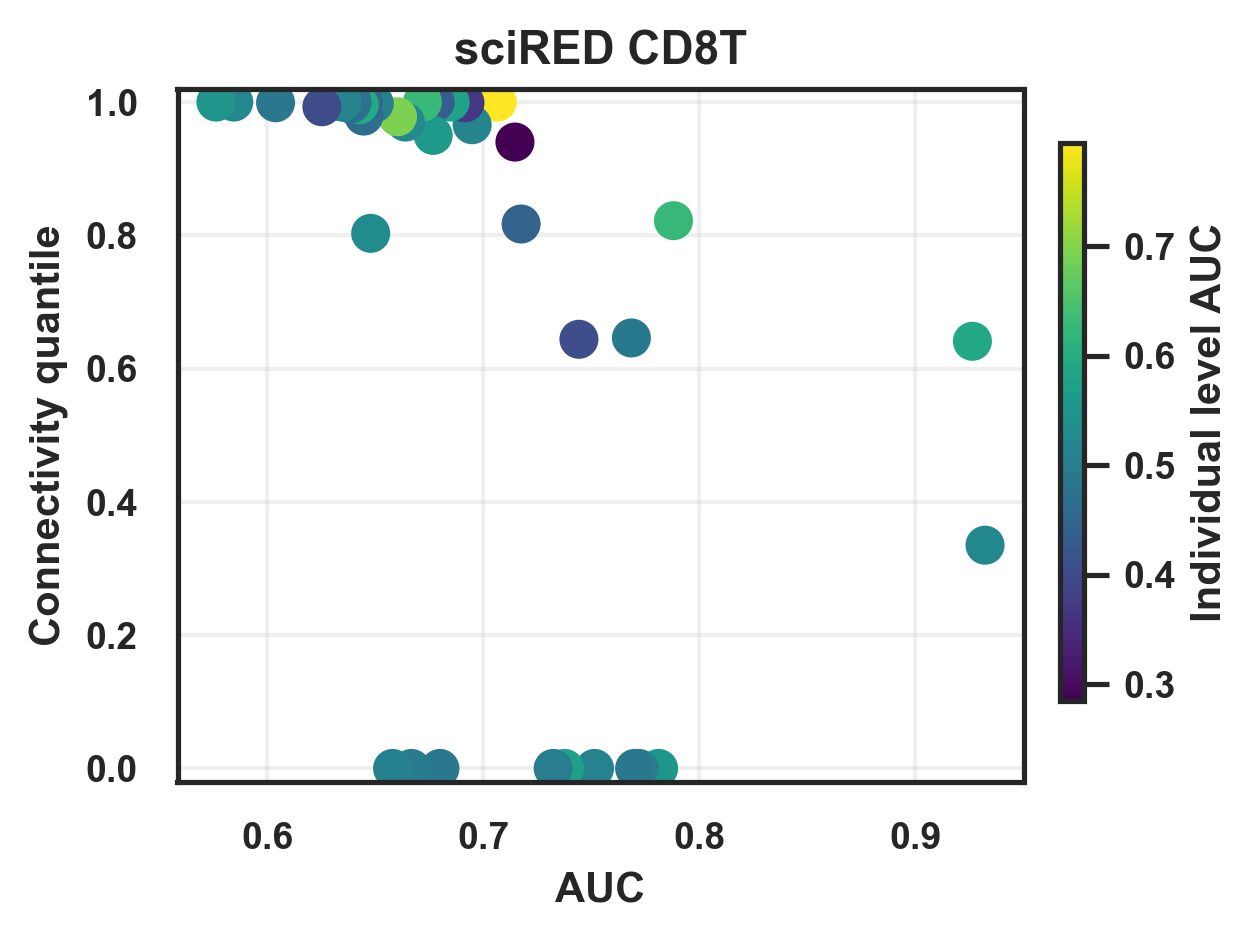

[SAVED] /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Yost_2019/figures/scired_ap.pdf


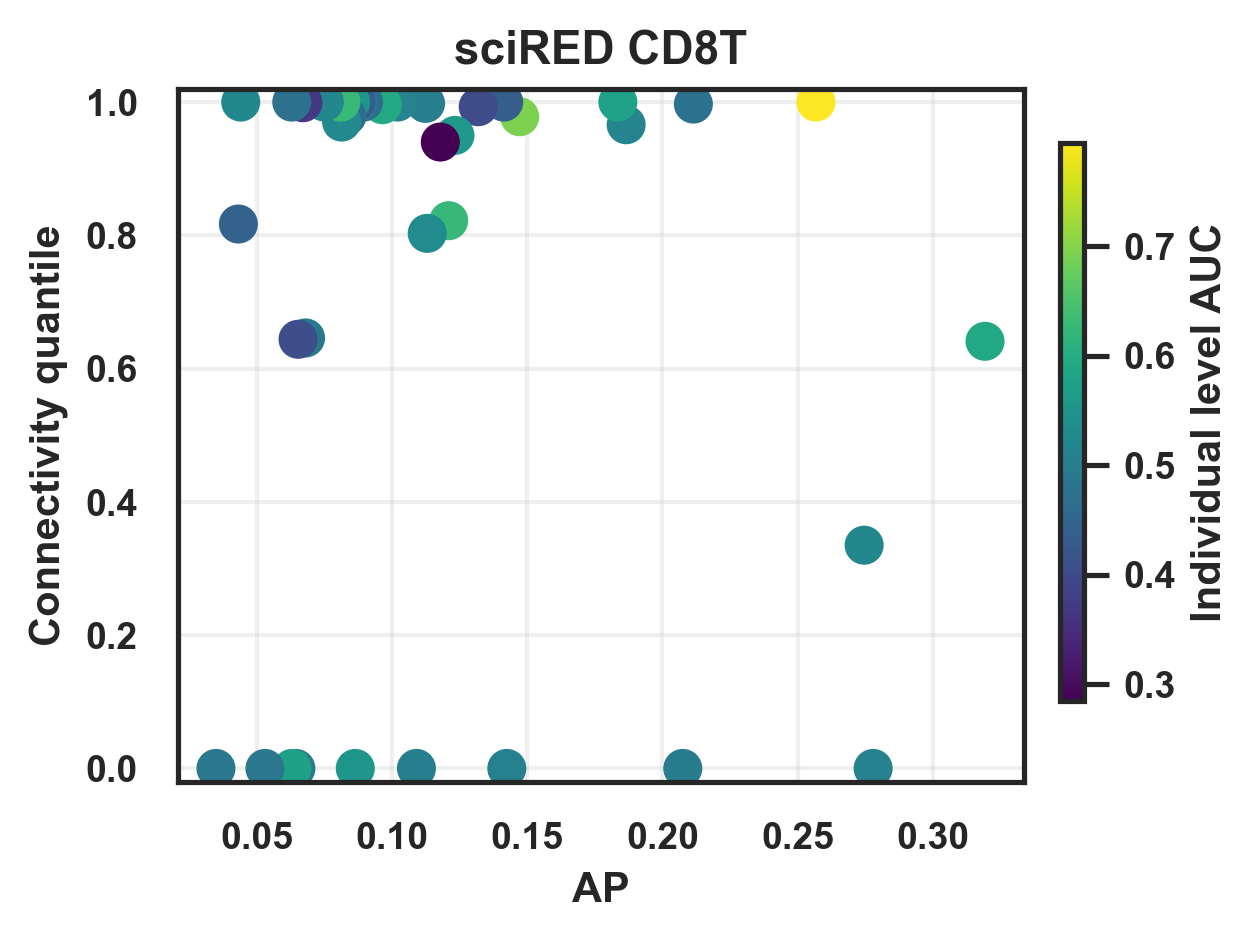

In [144]:
# SDAN vs sciRED: connectivity scatterplots for both Su_2020 cell types.

best_scired_ap = pd.read_csv(RESULTS_DIR / f"{DATASET}_best_matches_by_average_precision.csv")
best_scired_auroc = pd.read_csv(RESULTS_DIR / f"{DATASET}_best_matches_by_auroc.csv")
display(best_scired_ap.head())
display(best_scired_auroc.head())

plot_saved_best_match_score_1x2(
    best_scired_auroc,
    cell_types=DATASET_INFO["cell_types"],
    panel_titles=DATASET_INFO["scired_titles"],
    score_col="auroc",
    hue_col="individual_level_auroc",
    suptitle="",
    save_path=FIG_DIR / "scired_auc.pdf",
)

plot_saved_best_match_score_1x2(
    best_scired_ap,
    cell_types=DATASET_INFO["cell_types"],
    panel_titles=DATASET_INFO["scired_titles"],
    score_col="average_precision",
    hue_col="individual_level_auroc",
    suptitle="",
    save_path=FIG_DIR / "scired_ap.pdf",
)


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,CD8T,2.0,SDAN_1,Spectra_33,1259,1178,674,23,16,0.813260,0.321997,23,106,9.217391,1.000,0.474966,0.794388
1,CD8T,2.0,SDAN_34,Spectra_13,1259,1178,674,26,5,0.943498,0.263607,26,0,0.000000,0.000,0.477641,0.506318
2,CD8T,2.0,SDAN_21,Spectra_0,1259,1178,674,24,15,0.723723,0.201982,24,34,2.833333,1.000,0.501512,0.578937
3,CD8T,2.0,SDAN_14,Spectra_33,1259,1178,674,23,16,0.709062,0.179308,23,18,1.565217,0.996,0.540346,0.592998
4,CD8T,2.0,SDAN_19,Spectra_39,1259,1178,674,26,6,0.434132,0.174081,26,0,0.000000,0.000,0.483329,0.575301


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,CD8T,2.0,SDAN_34,Spectra_13,1259,1178,674,26,5,0.943498,0.263607,26,0,0.000000,0.000,0.477641,0.506318
1,CD8T,2.0,SDAN_30,Spectra_18,1259,1178,674,25,13,0.872687,0.154549,25,4,0.320000,0.641,0.531135,0.589954
2,CD8T,2.0,SDAN_27,Spectra_13,1259,1178,674,26,3,0.843020,0.094140,26,2,0.153846,0.335,0.511475,0.523066
3,CD8T,2.0,SDAN_32,Spectra_13,1259,1178,674,25,10,0.822590,0.046661,25,4,0.320000,0.646,0.517198,0.490571
4,CD8T,2.0,SDAN_1,Spectra_33,1259,1178,674,23,16,0.813260,0.321997,23,106,9.217391,1.000,0.474966,0.794388


[SAVED] /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Yost_2019/figures/spectra_auc.pdf


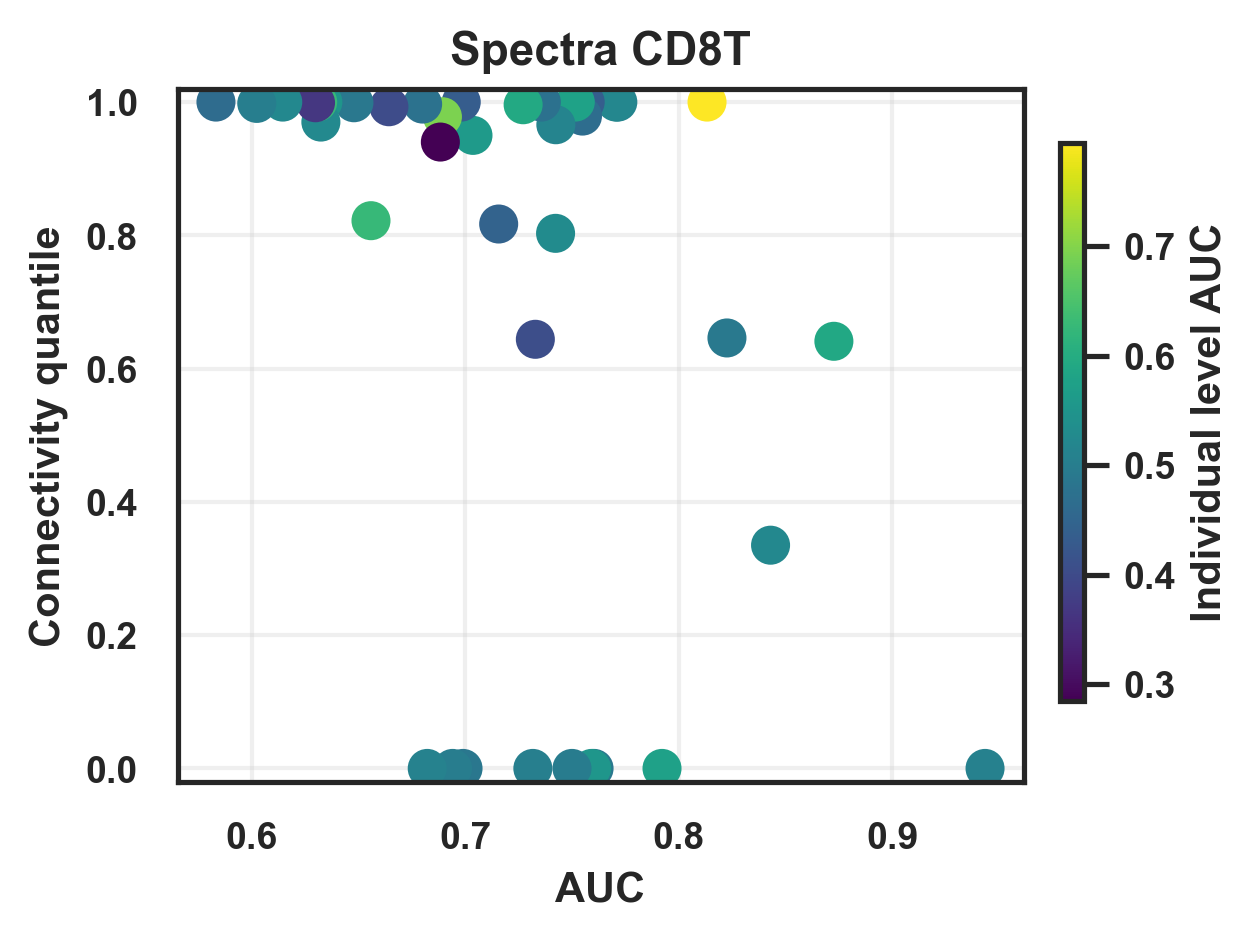

[SAVED] /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Yost_2019/figures/spectra_ap.pdf


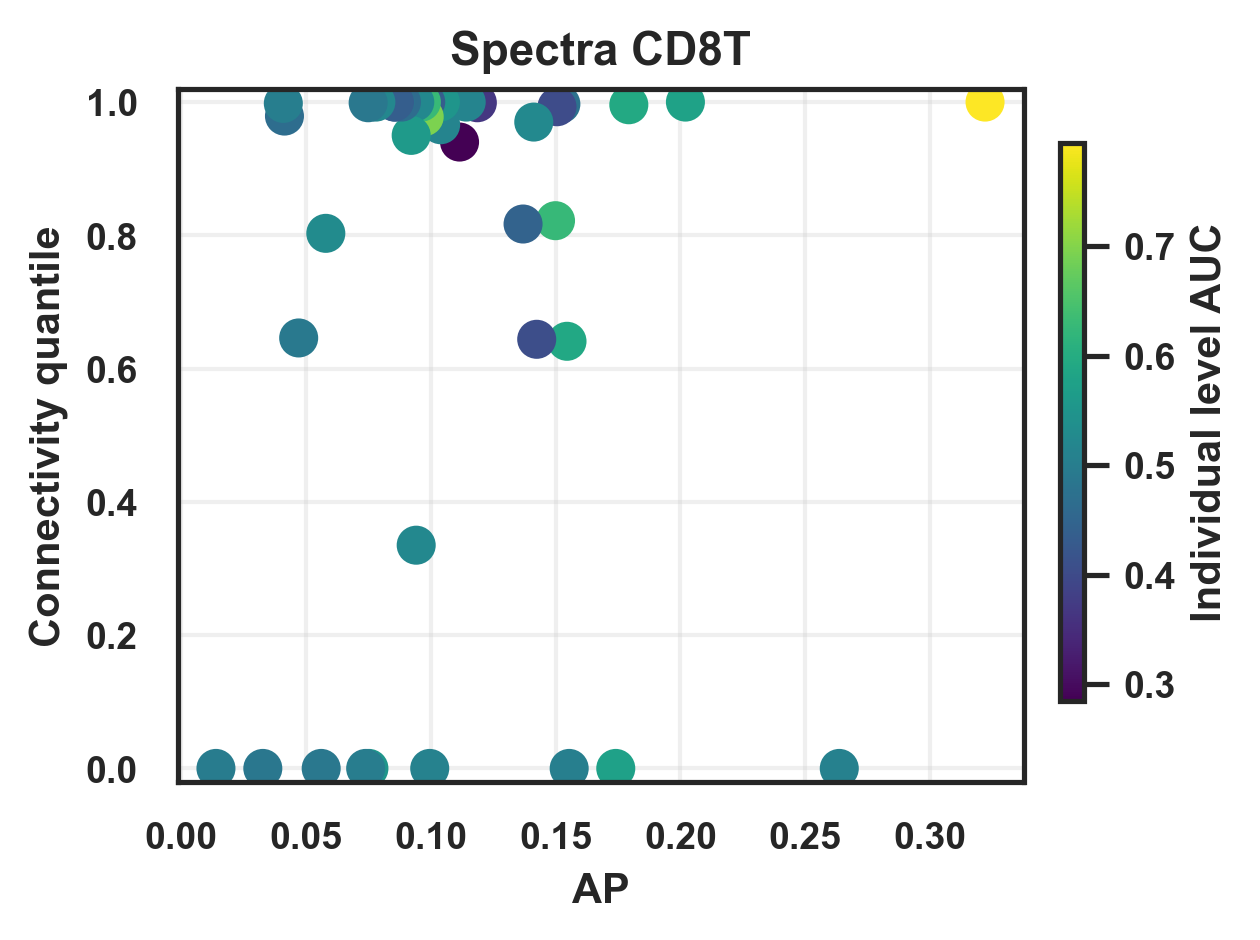

In [145]:
# SDAN vs Spectra: connectivity scatterplots for both Su_2020 cell types.

best_spectra_ap = pd.read_csv(SPECTRA_RESULTS_DIR / f"{DATASET}_best_Spectra_matches_by_average_precision.csv")
best_spectra_auroc = pd.read_csv(SPECTRA_RESULTS_DIR / f"{DATASET}_best_Spectra_matches_by_auroc.csv")
display(best_spectra_ap.head())
display(best_spectra_auroc.head())

plot_saved_best_match_score_1x2(
    best_spectra_auroc,
    cell_types=DATASET_INFO["cell_types"],
    panel_titles=DATASET_INFO["spectra_titles"],
    score_col="auroc",
    hue_col="individual_level_auroc",
    suptitle="",
    save_path=FIG_DIR / "spectra_auc.pdf",
)

plot_saved_best_match_score_1x2(
    best_spectra_ap,
    cell_types=DATASET_INFO["cell_types"],
    panel_titles=DATASET_INFO["spectra_titles"],
    score_col="average_precision",
    hue_col="individual_level_auroc",
    suptitle="",
    save_path=FIG_DIR / "spectra_ap.pdf",
)
